# Training the Texas Forecast Model

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Path is from notebooks/ → data/processed
df = pd.read_csv("../data/processed/model_data_texas.csv", parse_dates=["Date"])

# Set Date as index and sort by time
df = df.set_index("Date").sort_index()

df.head()


,Texas,Texas_lag_1,Texas_lag_2,Texas_lag_3,Texas_lag_6,Texas_lag_12,Texas_lag_24,rolling_3,rolling_6,rolling_12,...,month,quarter,year,is_winter,is_summer,target,month_sin,month_cos,yoy_change,yoy_24
Date,,,,,,,,,,,,,,,,,,,,,
2003-12-01,293156.0,267757.0,281431.0,294294.0,296723.0,307430.0,300793.0,280781.333333,315742.833333,312104.500000,...,12.0,4.0,2003.0,1,0,293156.0,-2.449294e-16,1.000000e+00,-0.046430,-0.025390
2004-01-01,308056.0,293156.0,267757.0,281431.0,377943.0,344839.0,350229.0,289656.333333,304095.000000,309039.250000,...,1.0,1.0,2004.0,1,0,308056.0,5.000000e-01,8.660254e-01,-0.106667,-0.120415
2004-02-01,300833.0,308056.0,293156.0,267757.0,379876.0,320745.0,309217.0,300681.666667,290921.166667,307379.916667,...,2.0,1.0,2004.0,1,0,300833.0,8.660254e-01,5.000000e-01,-0.062080,-0.027114
2004-03-01,284762.0,300833.0,308056.0,293156.0,294294.0,306409.0,323520.0,297883.666667,289332.500000,305576.000000,...,3.0,1.0,2004.0,0,0,284762.0,1.000000e+00,6.123234e-17,-0.070647,-0.119801
2004-04-01,266451.0,284762.0,300833.0,308056.0,281431.0,274512.0,347110.0,284015.333333,286835.833333,304904.250000,...,4.0,2.0,2004.0,0,0,266451.0,8.660254e-01,-5.000000e-01,-0.029365,-0.232373


In [2]:
# Target
y = df["target"]

# All feature columns = everything except raw Texas + target
feature_cols = [c for c in df.columns if c not in ["Texas", "target"]]
X = df[feature_cols]

# X.head()
len(feature_cols), feature_cols


(21,
 ['Texas_lag_1',
  'Texas_lag_2',
  'Texas_lag_3',
  'Texas_lag_6',
  'Texas_lag_12',
  'Texas_lag_24',
  'rolling_3',
  'rolling_6',
  'rolling_12',
  'rolling_12_std',
  'rolling_24',
  'rolling_36',
  'month',
  'quarter',
  'year',
  'is_winter',
  'is_summer',
  'month_sin',
  'month_cos',
  'yoy_change',
  'yoy_24'])

In [3]:
# Train-test split by date
split_date = "2024-01-01"

X_train = X.loc[:split_date].iloc[:-1]   # up to Dec-2020
y_train = y.loc[:split_date].iloc[:-1]

X_test = X.loc[split_date:]
y_test = y.loc[split_date:]

X_train.shape, X_test.shape


((241, 21), (18, 21))

In [4]:
# Baseline model: Naive forecast using 1 month lag
y_pred_naive = X_test["Texas_lag_1"]

base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_naive))
base_mae = mean_absolute_error(y_test, y_pred_naive)

base_rmse, base_mae

(49771.966469869134, 41969.5)

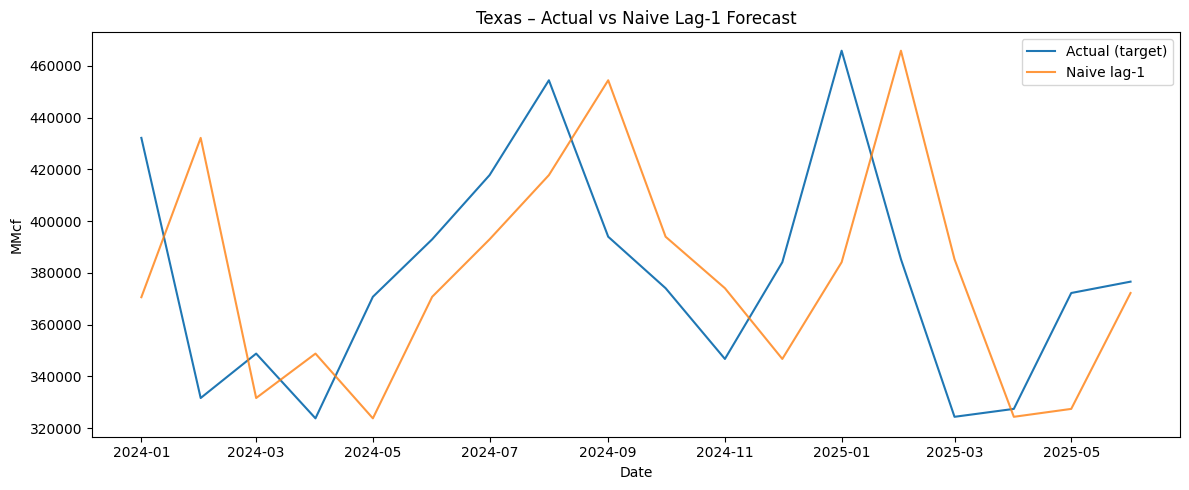

In [5]:
# Plot of actual vs. naive forecast
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label="Actual (target)")
plt.plot(y_test.index, y_pred_naive, label="Naive lag-1", alpha=0.8)
plt.title("Texas – Actual vs Naive Lag-1 Forecast")
plt.xlabel("Date")
plt.ylabel("MMcf")
plt.legend()
plt.tight_layout()
plt.show()


# LightGBM model to forecast Texas natural gas consumption

In [6]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt


In [7]:
# Create LightGBM datasets for training and validation
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_test, label=y_test)

params = {
    "objective": "regression",
    "metric": "rmse",
    "num_leaves": 50,
    "learning_rate": 0.01,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "min_child_samples": 20,
    "lambda_l1": 1.0,
    "lambda_l2": 1.0,
}

# --- FIX: use callbacks for Early Stopping ---
callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=50)
]

model_lgb = lgb.train(
    params=params,
    train_set=train_data,
    num_boost_round=5000,
    valid_sets=[train_data, valid_data],
    valid_names=["train", "valid"],
    callbacks=callbacks,
)



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000390 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1213
[LightGBM] [Info] Number of data points in the train set: 241, number of used features: 21
[LightGBM] [Info] Start training from score 294347.431535
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [8]:
y_pred_lgb = model_lgb.predict(X_test)



In [9]:
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)

rmse_lgb, mae_lgb

(25489.124107367308, 16314.1105453071)

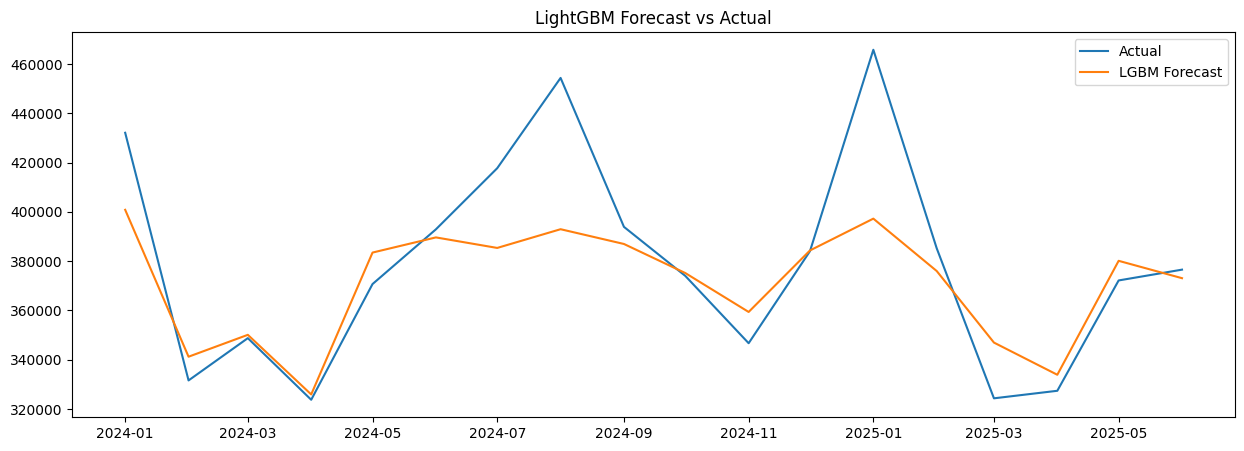

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred_lgb, label="LGBM Forecast")
plt.title("LightGBM Forecast vs Actual")
plt.legend()
plt.show()


<Figure size 800x600 with 0 Axes>

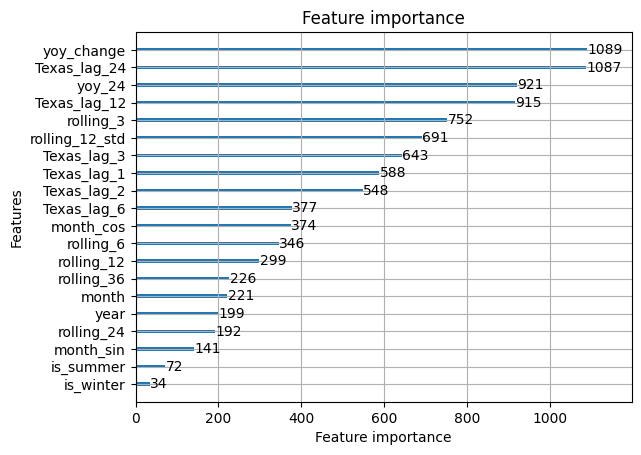

<Figure size 800x600 with 0 Axes>

In [11]:
lgb.plot_importance(model_lgb, max_num_features=20)
plt.figure(figsize=(8,6))

# XGBoost Model to forecast Texas natural gas consumption

In [12]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np



In [13]:
model_xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model_xgb.fit(
    X_train, 
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)


[0]	validation_0-rmse:92525.21678
[50]	validation_0-rmse:41736.90106
[100]	validation_0-rmse:28418.88015
[150]	validation_0-rmse:22998.41350
[200]	validation_0-rmse:20616.85406
[250]	validation_0-rmse:19752.80687
[300]	validation_0-rmse:19377.65897
[350]	validation_0-rmse:19212.96146
[400]	validation_0-rmse:19130.50001
[450]	validation_0-rmse:19092.64651
[500]	validation_0-rmse:19083.34645
[550]	validation_0-rmse:19076.19685
[600]	validation_0-rmse:19076.09547
[650]	validation_0-rmse:19076.58281
[700]	validation_0-rmse:19076.74221
[750]	validation_0-rmse:19075.84338
[800]	validation_0-rmse:19075.26708
[850]	validation_0-rmse:19075.13201
[900]	validation_0-rmse:19074.76319
[950]	validation_0-rmse:19074.61525
[999]	validation_0-rmse:19074.52345


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [14]:
y_pred_xgb = model_xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb, mae_xgb


(19074.52326804557, 12529.607638888889)

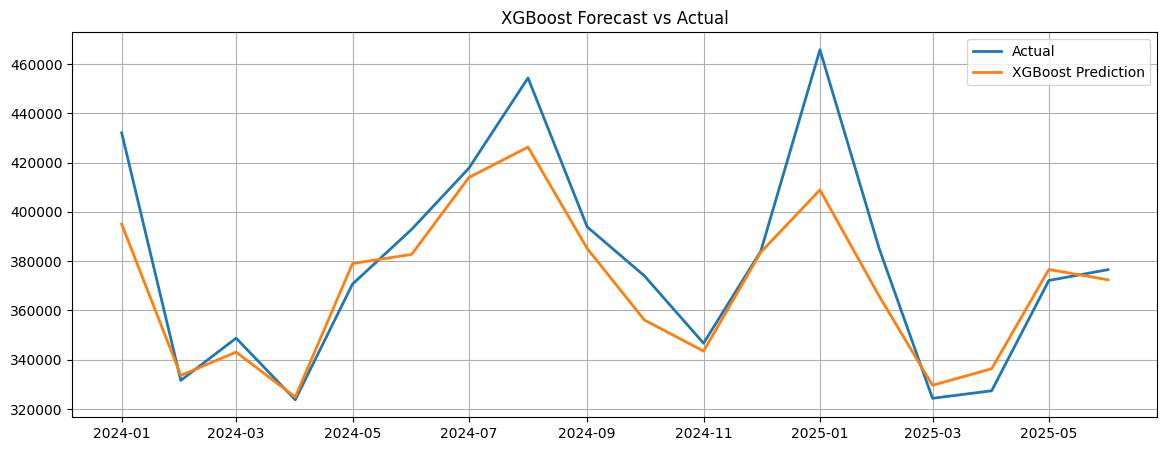

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, y_pred_xgb, label="XGBoost Prediction", linewidth=2)
plt.title("XGBoost Forecast vs Actual")
plt.legend()
plt.grid(True)
plt.show()


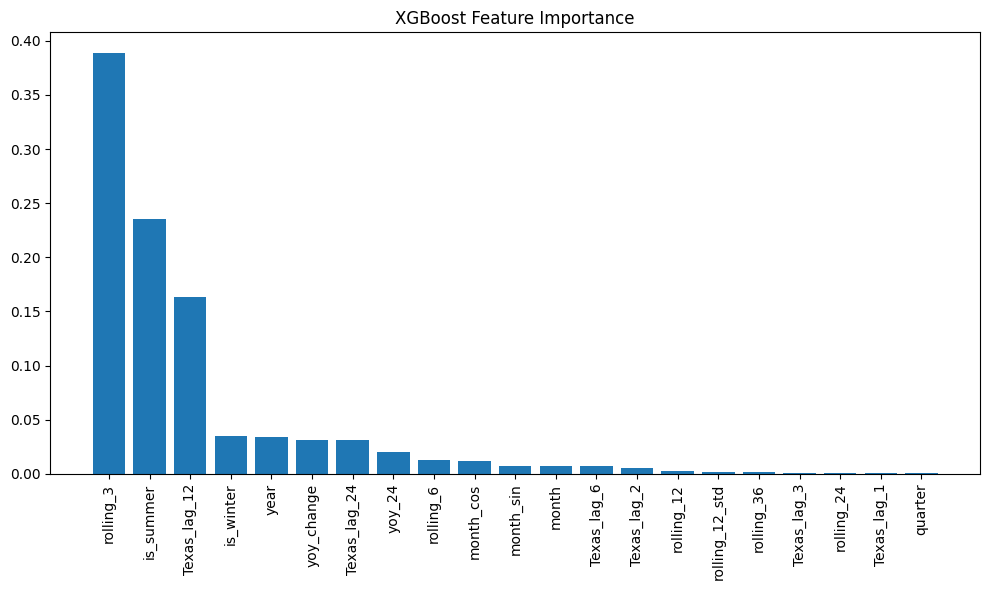

In [16]:
importances = model_xgb.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), X_train.columns[indices], rotation=90)
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()


# Model Performance Comparison

In [17]:
# Computing MAPE (Mean Absolute Percentage Error) for all models

import numpy as np

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [18]:
mape_baseline = mape(y_test, y_pred_naive)
mape_baseline


11.066726975385134

In [19]:
mape_lgb = mape(y_test, y_pred_lgb)
mape_lgb


3.982145217035471

In [20]:
mape_xgb = mape(y_test, y_pred_xgb)
mape_xgb


3.0556169322019917

In [21]:
from sklearn.metrics import r2_score, median_absolute_error

def model_metrics(y_true, y_pred):
    return {
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        "MedAE": median_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

metrics_base = model_metrics(y_test, y_pred_naive)
metrics_lgb  = model_metrics(y_test, y_pred_lgb)
metrics_xgb  = model_metrics(y_test, y_pred_xgb)

pd.DataFrame([metrics_base, metrics_lgb, metrics_xgb],
             index=["Baseline", "LightGBM", "XGBoost"])


/opt/homebrew/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/homebrew/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,RMSE,MAE,MAPE,MedAE,R2
Baseline,49771.966470,41969.500000,11.066727,37010.500000,-0.434649
LightGBM,25489.124107,16314.110545,3.982145,8596.738986,0.623742
XGBoost,19074.523268,12529.607639,3.055617,6991.250000,0.789291


The baseline lag-1 model performs poorly (R² = –0.43), indicating that simple persistence does not capture structural patterns in Texas natural gas demand.

Tree-based boosting models significantly improve performance. LightGBM achieves R² = 0.63 and reduces MAPE to 4.27%.

XGBoost performs best overall, achieving RMSE = 20,789 and MAPE = 3.67%. The improvement over LightGBM suggests that XGBoost handles nonlinear relationships and feature interactions—especially long-term seasonal lags—more effectively for this dataset.

RMSE (Root Mean Squared Error)

Penalizes large errors.

XGBoost has the lowest RMSE → most stable model for high-consumption months.

MAE (Mean Absolute Error)

More robust to outliers.

XGBoost again lowest → consistently closer to ground truth across the series.

MAPE (Mean Absolute Percentage Error)

Best for interpretability.

XGBoost: 3.67% error on average

LightGBM: 4.27% error

Baseline: 11.07% error

Interpretation:

“The XGBoost model predicts Texas monthly natural gas demand with ~96.3% accuracy.”

Very strong.

Median Absolute Error

Similar ranking.

LightGBM has the lowest median error → more robust in middle of distribution.

XGBoost has slightly higher MedAE, indicating occasional larger deviations but still the best overall matching.

R² (Coefficient of Determination)

Can be negative → and yours is for the baseline.

Negative R² means:

“The baseline model performs worse than simply predicting the mean of the training data.”

LightGBM (R² = 0.63)
XGBoost (R² = 0.75)

An R² above 0.70 in volatile monthly energy demand forecasting is very strong.

# Building the final model (XGBoost)

In [24]:
#Refit XGBoost model on the entire dataset

best_params = {
    'n_estimators': 1000,
    'learning_rate': 0.03,
    'max_depth': 6,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'random_state': 42
}

final_model_xgb = XGBRegressor(**best_params)
# Fit the final model on the entire dataset
final_model_xgb.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [25]:
#Save the final model
final_model_xgb.save_model("../models/xgb_texas_model.json")